In [31]:
import numpy as np
import pandas as pd
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import RMSprop


In [32]:
df = pd.read_csv("hou_all.csv")
## 2. Load Boston Housing Dataset
## (Available directly in Keras)
(X_train, Y_train), (X_test, Y_test) = keras.datasets.boston_housing.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
print("Train output data shape:", Y_train.shape)
print("Actual Test output data shape:", Y_test.shape)

Training data shape: (404, 13)
Test data shape: (102, 13)
Train output data shape: (404,)
Actual Test output data shape: (102,)


In [33]:
# 3. Feature Scaling (Important for DNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

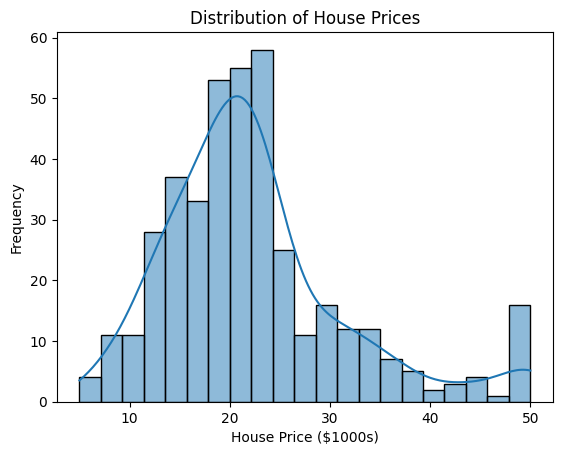

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(Y_train, kde=True)
plt.xlabel("House Price ($1000s)")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()

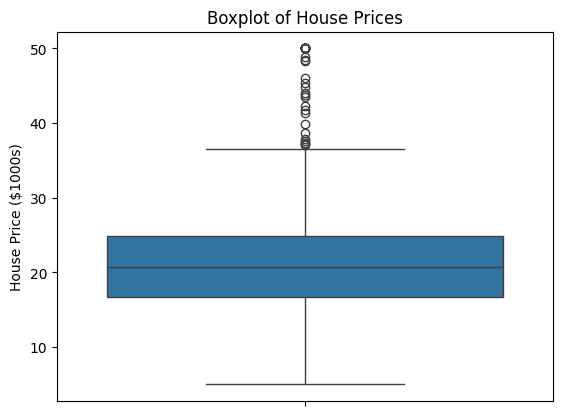

In [35]:
sns.boxplot(y=Y_train)
plt.ylabel("House Price ($1000s)")
plt.title("Boxplot of House Prices")
plt.show()

In [36]:
import pandas as pd

df = pd.DataFrame(X_train)

In [37]:
df.columns = [
    'CRIM','ZN','INDUS','CHAS','NOX','RM','AGE',
    'DIS','RAD','TAX','PTRATIO','B','LSTAT'
]

In [38]:
df['PRICE'] = Y_train


In [39]:
correlation = df.corr()

In [40]:
correlation['PRICE']

,PRICE
CRIM,-0.378498
ZN,0.380299
INDUS,-0.476743
CHAS,0.168661
NOX,-0.438328
RM,0.681483
AGE,-0.364173
DIS,0.253900
RAD,-0.375515
TAX,-0.448737


<Axes: >

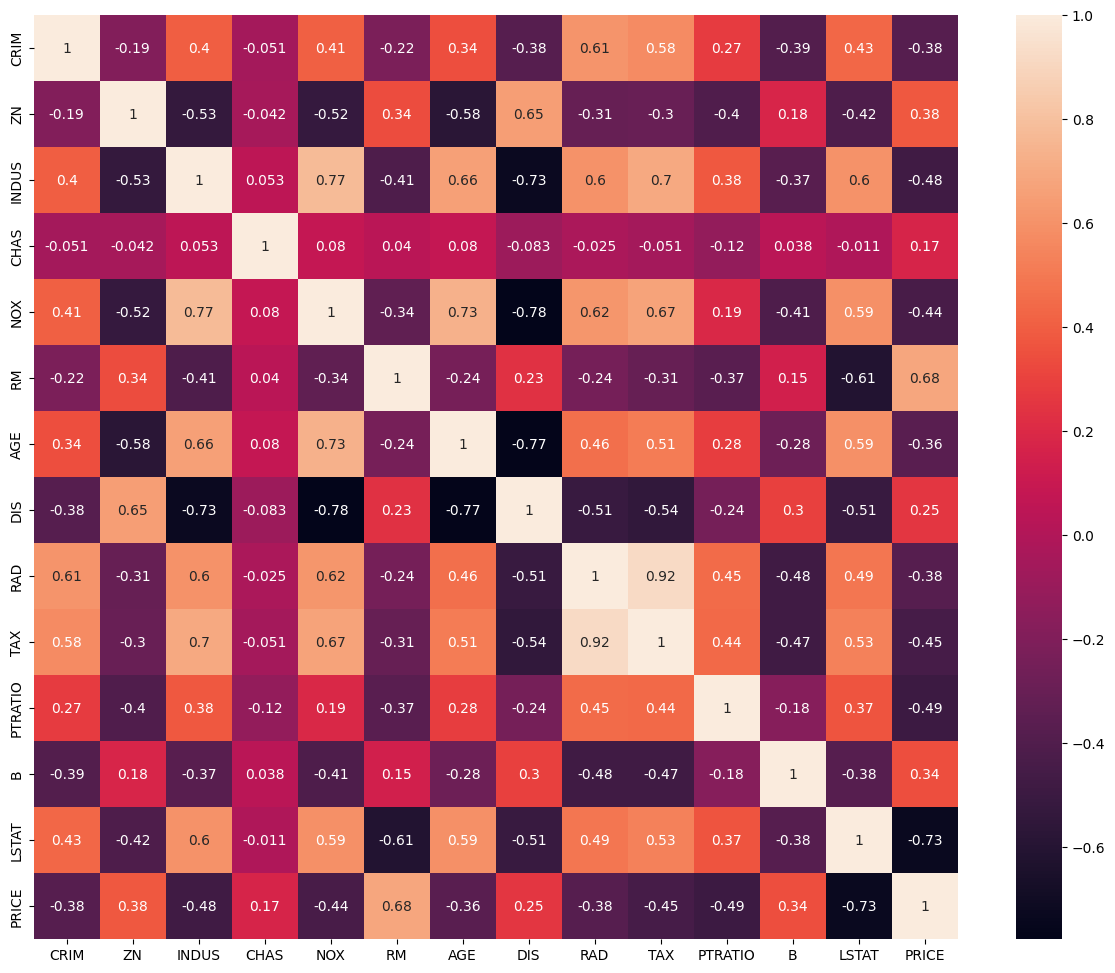

In [41]:
fig,axes = plt.subplots(figsize=(15,12))
sns.heatmap(correlation,square = True,annot = True)

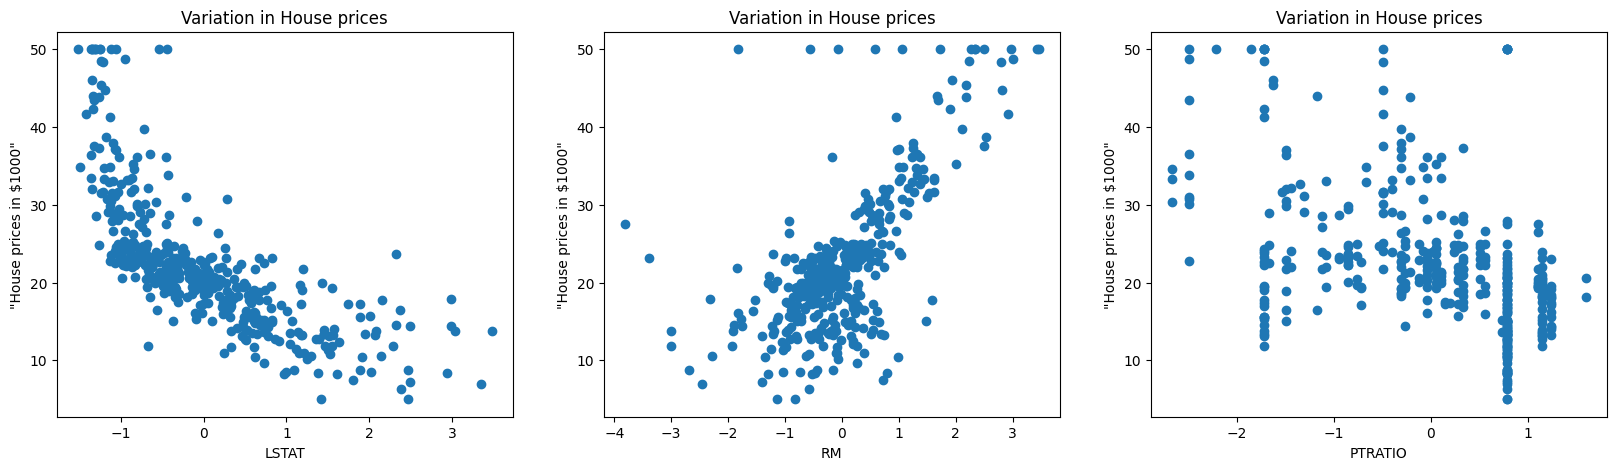

In [42]:
plt.figure(figsize = (20,5))
features = ['LSTAT','RM','PTRATIO']
for i, col in enumerate(features):
    plt.subplot(1, len(features) , i+1)
    x = df[col]
    y = df.PRICE
    plt.scatter(x, y, marker='o')
    plt.title("Variation in House prices")
    plt.xlabel(col)
    plt.ylabel('"House prices in $1000"')

In [43]:
# 4. Build Deep Neural Network Model
model = Sequential()
model.add(Dense(128,activation='relu',input_shape= X_train[0].shape))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1))

model.summary()

model.compile(loss='mse',optimizer='rmsprop',metrics=['mae'])

history = model.fit(X_train,Y_train,epochs=50,batch_size=1,verbose=1,validation_data=(X_test,Y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 90.6876 - mae: 6.4339 - val_loss: 20.0194 - val_mae: 3.4227
Epoch 2/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 19.4347 - mae: 2.9904 - val_loss: 19.4274 - val_mae: 3.1516
Epoch 3/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 15.9626 - mae: 2.7791 - val_loss: 20.4130 - val_mae: 2.9776
Epoch 4/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.5854 - mae: 2.5631 - val_loss: 23.0202 - val_mae: 3.2528
Epoch 5/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13.0054 - mae: 2.4683 - val_loss: 22.4690 - val_mae: 3.0673
Epoch 6/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11.2784 - mae: 2.2946 - val_loss: 24.2329 - val_mae: 3.3798
Epoch 7/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 12.0091 - mae: 2.3281 - val_loss: 19.9193 - val_mae: 2.7605
Epoch 8/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 10.7853 - mae: 2.3239 - val_loss: 21.2558 - val_mae: 3.0427
Epoch 9/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 

In [44]:
y_pred=model.predict(X_test)
mse_nn, mae_nn = model.evaluate(X_test, Y_test)
print('Mean squared error on test data: ', mse_nn)
print('Mean absolute error on test data: ', mae_nn)
y_pred

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10.6122 - mae: 2.2608 
Mean squared error on test data:  10.612234115600586
Mean absolute error on test data:  2.2607975006103516


array([[ 7.7074137],
       [18.455837 ],
       [20.466665 ],
       [33.257507 ],
       [23.971087 ],
       [23.181555 ],
       [29.760107 ],
       [22.363302 ],
       [19.568893 ],
       [19.959002 ],
       [17.346117 ],
       [17.335579 ],
       [14.333857 ],
       [43.65103  ],
       [20.203382 ],
       [21.670588 ],
       [25.75207  ],
       [17.826027 ],
       [19.110582 ],
       [19.942827 ],
       [11.539754 ],
       [ 9.771273 ],
       [20.25532  ],
       [16.293072 ],
       [19.909342 ],
       [21.223421 ],
       [25.703392 ],
       [29.803366 ],
       [10.612633 ],
       [20.929953 ],
       [19.281664 ],
       [13.946655 ],
       [32.706158 ],
       [24.10172  ],
       [17.98704  ],
       [ 8.8918495],
       [17.936106 ],
       [17.345972 ],
       [16.310745 ],
       [26.298246 ],
       [31.921719 ],
       [28.344582 ],
       [12.30932  ],
       [44.742123 ],
       [27.952772 ],
       [27.734903 ],
       [27.11281  ],
       [20.42